In [1]:
import os
import numpy as np
import pandas as pd
import scipy as sp
import topas2numpy as tn
import matplotlib.pyplot as plt
from ipywidgets import interact
import matplotlib.colors as colors
import matplotlib.ticker as ticker
from tqdm import tqdm

import seaborn as sns

import sys
sys.path.append('..')
from preprocessSimulation import Preprocessor
from simulation import Simulation, SimulationSeries


In [2]:
root = 'H:/EIT/Christoph/Monte_Carlo/05_motor_servo_wood_air_cylinder_setupA'

folders = [f for f in os.listdir(root) if os.path.isdir(os.path.join(root, f)) and f.startswith('F7x1')]
print(folders)

simulations = {}
for folder in folders[:23]:
    path_dose = f"{root}/{folder}/DoseGrid.csv"
    path_current_elX = f"{root}/{folder}/velCurrElX.csv"
    path_current_elY = f"{root}/{folder}/velCurrElY.csv"
    path_current_elZ = f"{root}/{folder}/velCurrElZ.csv"

    bin_x = 0.5
    bin_y = 0.5
    bin_z = 0.1

    data = Preprocessor([path_dose, path_current_elX, path_current_elY, path_current_elZ], bin_x, bin_y, bin_z, center=True).data
    simulations[folder] = Simulation(data)

['F7x1_S0', 'F7x1_S0.25', 'F7x1_S0.5', 'F7x1_S0.75', 'F7x1_S1', 'F7x1_S1.25', 'F7x1_S1.5', 'F7x1_S1.75', 'F7x1_S2', 'F7x1_S2.25', 'F7x1_S2.5', 'F7x1_S2.75', 'F7x1_S3', 'F7x1_S3.25', 'F7x1_S3.5', 'F7x1_S3.75', 'F7x1_S4', 'F7x1_S4.25', 'F7x1_S4.5', 'F7x1_S4.75', 'F7x1_S5', 'F7x1_S5.25', 'F7x1_S5.5', 'F7x1_S5.75', 'F7x1_S6', 'F7x1_S6.25', 'F7x1_S6.5', 'F7x1_S6.75', 'F7x1_S7']
Loading data from H:/EIT/Christoph/Monte_Carlo/05_motor_servo_wood_air_cylinder_setupA/F7x1_S0/DoseGrid.csv...
Loading data from H:/EIT/Christoph/Monte_Carlo/05_motor_servo_wood_air_cylinder_setupA/F7x1_S0/velCurrElX.csv...
Loading data from H:/EIT/Christoph/Monte_Carlo/05_motor_servo_wood_air_cylinder_setupA/F7x1_S0/velCurrElY.csv...
Loading data from H:/EIT/Christoph/Monte_Carlo/05_motor_servo_wood_air_cylinder_setupA/F7x1_S0/velCurrElZ.csv...
Range x: 0 to 60
Range y: 0 to 60
Range z: 0 to 199
Range x: -30 to 30
Range y: -30 to 30
Range z: 0 to 199
Calculated radial distances from 0.0 to 42.42640687119285 with cen

## Calculate simulated current densities

In [3]:

# variance = [0.5, 3.5, 15]
variance = [15]
electrodes = [3.8, 4.6, 5.4, 6.2, 7.0, 16.0, 16.8, 17.6, 18.4, 19.2]

for j, (folder, simulation) in enumerate(tqdm(simulations.items())):
    for i, var in enumerate(variance):
        simulation.filter_plane_width(halfwidth=var)

        for k in range(1, len(electrodes)):
            z_min = electrodes[k-1]
            z_max = electrodes[k]
            simulation.integrate_current(z_min, z_max, pos=k-1, halfwidth=var)

print(f"Simulated results for halfwidths: {variance} - {list(simulations.values())[0].currentX.keys()}")

100%|██████████| 23/23 [00:08<00:00,  2.59it/s]

Simulated results for halfwidths: [15] - dict_keys([(0, 15), (1, 15), (2, 15), (3, 15), (4, 15), (5, 15), (6, 15), (7, 15), (8, 15)])


## Calculate measured current densities

In [4]:
from measurement import Measurement

measurement = Measurement(data_path="H:/EIT/Christoph/experiments/data/07_slab_phantom_wood_slabs_triangle_rod/data_16.dat", motor_path="H:/EIT/Christoph/experiments/data/07_slab_phantom_wood_slabs_triangle_rod/motor_16.csv", time_offset=-1.25, gantry=90, energy="10MV FFF", field_size="7x1cm", mu=1500, mu_rate=2400, sampling_rate=100, notes="motion +-7cm, 18s")
measurement.calculate_currents()


Cleaning channel 0...
Cleaning channel 1...
Cleaning channel 2...
Cleaning channel 3...
Cleaning channel 4...
Cleaning channel 5...
Cleaning channel 6...
Cleaning channel 7...
Detect signal window for channels: [0, 1, 2, 3, 4, 5, 6, 7]
[separate_signal_components] fs=100.000 Hz | motion≈0.1667 Hz (band 0.0417–10.0000 Hz) | baseline_win≈3000 samples (30.00 s) | noise_hp=25.000 Hz


## Combine signals from measurement and simulation

In [5]:
class SimulationSeries:
    def __init__(self, simulations: dict[str, Simulation], measurement):
        self.simulations = simulations
        self.measurement = measurement

    def get_simulated_signal(self, halfwidth: float = None) -> None:
        self.simulation_signals = {i-1: {} for i in range(1, self.measurement.num_channels+1)}
        if halfwidth is None:
            halfwidth = (list(self.simulations.values())[0].dimensions[0][1] - list(self.simulations.values())[0].dimensions[0][0]) / 2
        for name, sim in self.simulations.items():
            transl = float(name.split('S')[1]) * 10
            print(f"Processing simulation {name} with currents: {sim.currentX.keys()}")
            for i in range(1, self.measurement.num_channels+1):
                # currX0 = sim.currentX[(i-1, halfwidth)]
                # currX1 = sim.currentX[(i, halfwidth)]

                # currY0 = sim.currentY[(i-1, halfwidth)]
                # currY1 = sim.currentY[(i, halfwidth)]

                currZ0 = sim.currentZ[(i-1, halfwidth)]
                currZ1 = sim.currentZ[(i, halfwidth)]
                
                # sig = (currX1 - currX0) + (currY1 - currY0) + (currZ1 - currZ0)
                sig = (currZ1 - currZ0)
                self.simulation_signals[i-1][transl] = sig
                if transl != 0:
                    self.simulation_signals[i-1][-transl] = sig
                self.simulation_signals[i-1] = {key:self.simulation_signals[i-1][key] for key in sorted(self.simulation_signals[i-1].keys())}
        print(f"Final simulation signals for channel 0: {list(self.simulation_signals[0].values())}")
        

    def plot_all_channels(self, variable: str = None, show: bool = True, save: bool = False, outdir = None, xlim = None):
        
        if variable in ['time', 'position']:
            fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True, constrained_layout=True)
            axes = axes.ravel()
            figs = [(fig, axes, variable)]
        else:
            figs = []
            for var in ['time', 'position']:
                fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True, constrained_layout=True)
                axes = axes.ravel()
                figs.append((fig, axes, var))

        m = self.measurement
        for fig, axes, variable in figs:
            for ch in range(m.num_channels):
                ax = axes[ch]
                
                if variable in ['time', 'position']:
                    self._show_measurements(ch, ax, variable=variable)
                else: 
                    for var in ['time', 'position']:
                        self._show_measurements(ch, ax, variable=var)
                ax.set_title(f"Channel {ch}")
                ax.grid(True, alpha=0.3)

                if xlim is not None:
                    ax.set_xlim(*xlim)

            fig.suptitle(f"Gantry: {m.gantry}°, Energy: {m.energy}, Field: {m.field_size}, Sampling Rate: {m.sampling_rate}Hz")
            
            fig.supxlabel("Time [s]" if variable == 'time' else "Position [mm]")
            fig.supylabel("Baseline-corrected signal [uV]")

            if save:
                base_name = os.path.splitext(os.path.basename(m.data_path))[0]
                fname = f"{base_name}_all_{m.energy}_{m.field_size}_{m.sampling_rate}Hz_{variable}.pdf"
                os.makedirs(outdir, exist_ok=True) if outdir else None
                outpath = os.path.join(outdir, fname) if outdir else fname
                fig.savefig(outpath, dpi=200)

        if show:
            plt.show()
        else:
            plt.close(fig)


    def _show_measurements(self, ch: int, ax: plt.Axes, variable: str = 'time'):
        """
        Plot all runs of a measurement on a single axis.
        """

        label = self.measurement.notes if isinstance(self.measurement.notes, str) and self.measurement.notes else f"channel {ch}"
        ax2 = ax.twinx()
        if variable == 'time':
            ax.plot(self.measurement.timestamp, self.measurement.channels_components["signal_filter"][ch], alpha=0.7, label=label)
            # # ax.vlines(self.measurement.features['signal_window'][ch], ymin=-500, ymax=500, colors='gray', linestyles='dashed', alpha=0.3, label=f"{label} (signal window)")
            ax2.plot(self.measurement.motor_signal['timestamp'], self.measurement.motor_signal['position'], label="Motor position", linestyle=':')

        elif variable == 'position':
            ax.plot(self.measurement.position, self.measurement.channels_components["signal_filter"][ch], alpha=0.7, label=label)
            ax2.plot(self.simulation_signals[ch].keys(), self.simulation_signals[ch].values(), marker='o', label="Simulated current", color="tab:orange", linestyle='--')
            # ax2.plot(self.simulation_signals[ch].keys(), 10 * np.gradient(list(self.simulation_signals[ch].values())), marker='o', label="Simulated current derivative", color="tab:purple", linestyle=':')
            ax2.plot(self.simulation_signals[ch].keys(), list(self.simulation_signals[ch].values()) + 3 * np.gradient(list(self.simulation_signals[ch].values())), marker='o', label=r"Simulated $v_x>0$", color="tab:green", linestyle=':')
            ax2.plot(self.simulation_signals[ch].keys(), list(self.simulation_signals[ch].values()) - 3 * np.gradient(list(self.simulation_signals[ch].values())), marker='o', label=r"Simulated $v_x<0$", color="tab:blue", linestyle=':')
            # ax2.plot(self.measurement.motor_signal['position'], self._cylinder_mass_in_beam(r=25, w_x=10, w_y=70, rho=0.6)[1], label=f"{label} (estimated mass in beam)", color='red', linestyle=':')
        lns1, lbs1 = ax.get_legend_handles_labels()
        lns2, lbs2 = ax2.get_legend_handles_labels()
        ax2.legend(lns1 + lns2, lbs1 + lbs2, loc='best', fontsize='small')


    def _cylinder_mass_in_beam(self, r: float = 25, w_x: float = 70, w_y: float = 70, rho: float = 0.6):
        volume = []
        mass = []
        
        for pos in self.measurement.motor_signal['position']:
            x_a = -w_x / 2.0
            x_b = w_x / 2.0

            thickness = lambda x_beam, x: 2.0 * np.sqrt(max(0.0, r**2 - (x_beam - x)**2))

            x_beam = np.linspace(x_a, x_b, 1000)
            thickness_profile = [thickness(x, pos) for x in x_beam]
            vol = np.trapezoid(thickness_profile, x_beam) * w_y # mm^3
            m = vol * rho  # g/mm^3
            volume.append(vol)
            mass.append(m)

        return volume, mass


Processing simulation F7x1_S0 with currents: dict_keys([(0, 15), (1, 15), (2, 15), (3, 15), (4, 15), (5, 15), (6, 15), (7, 15), (8, 15)])
Processing simulation F7x1_S0.25 with currents: dict_keys([(0, 15), (1, 15), (2, 15), (3, 15), (4, 15), (5, 15), (6, 15), (7, 15), (8, 15)])
Processing simulation F7x1_S0.5 with currents: dict_keys([(0, 15), (1, 15), (2, 15), (3, 15), (4, 15), (5, 15), (6, 15), (7, 15), (8, 15)])
Processing simulation F7x1_S0.75 with currents: dict_keys([(0, 15), (1, 15), (2, 15), (3, 15), (4, 15), (5, 15), (6, 15), (7, 15), (8, 15)])
Processing simulation F7x1_S1 with currents: dict_keys([(0, 15), (1, 15), (2, 15), (3, 15), (4, 15), (5, 15), (6, 15), (7, 15), (8, 15)])
Processing simulation F7x1_S1.25 with currents: dict_keys([(0, 15), (1, 15), (2, 15), (3, 15), (4, 15), (5, 15), (6, 15), (7, 15), (8, 15)])
Processing simulation F7x1_S1.5 with currents: dict_keys([(0, 15), (1, 15), (2, 15), (3, 15), (4, 15), (5, 15), (6, 15), (7, 15), (8, 15)])
Processing simulation

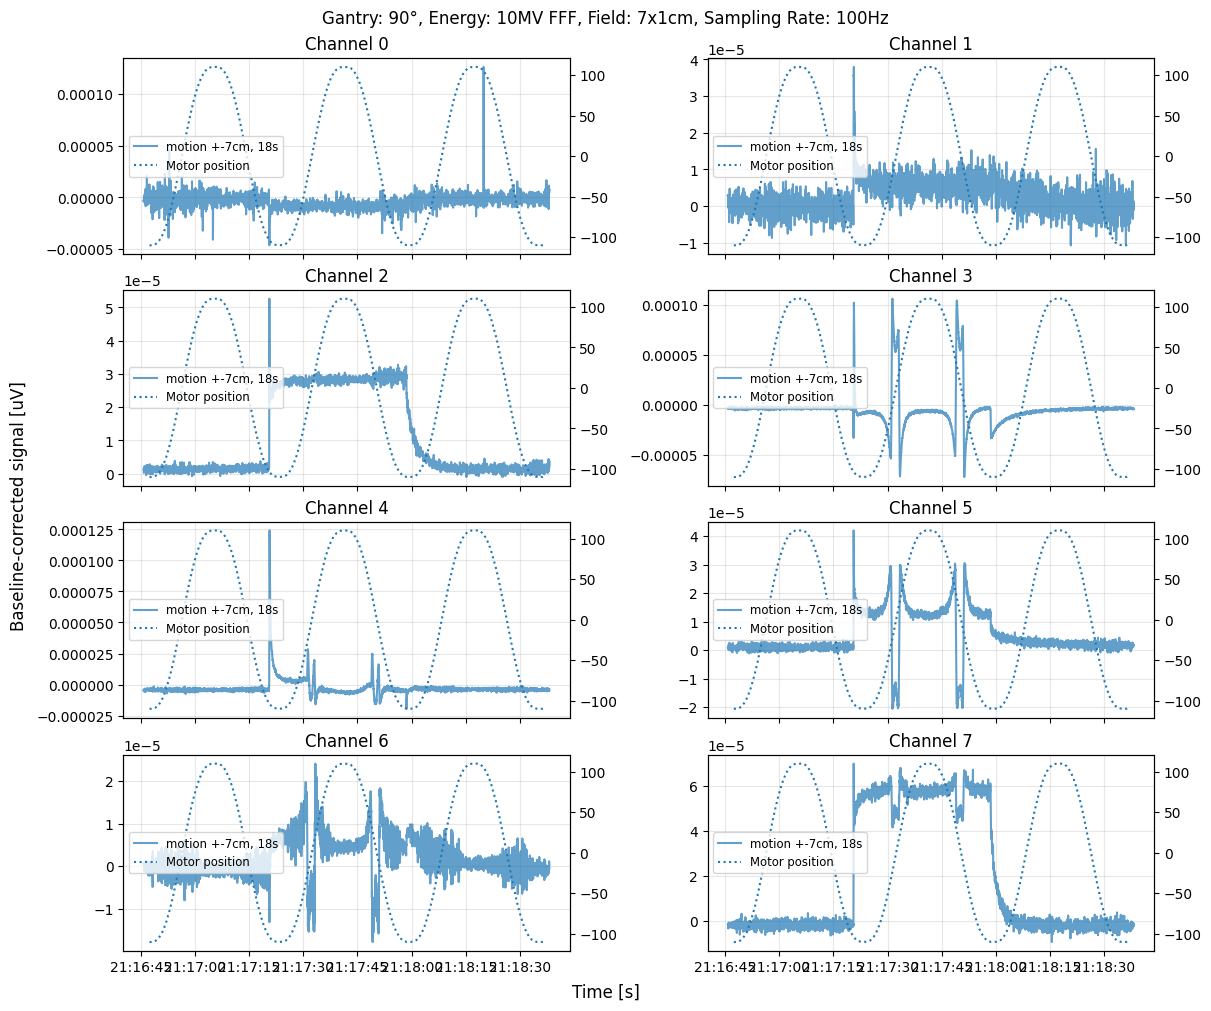

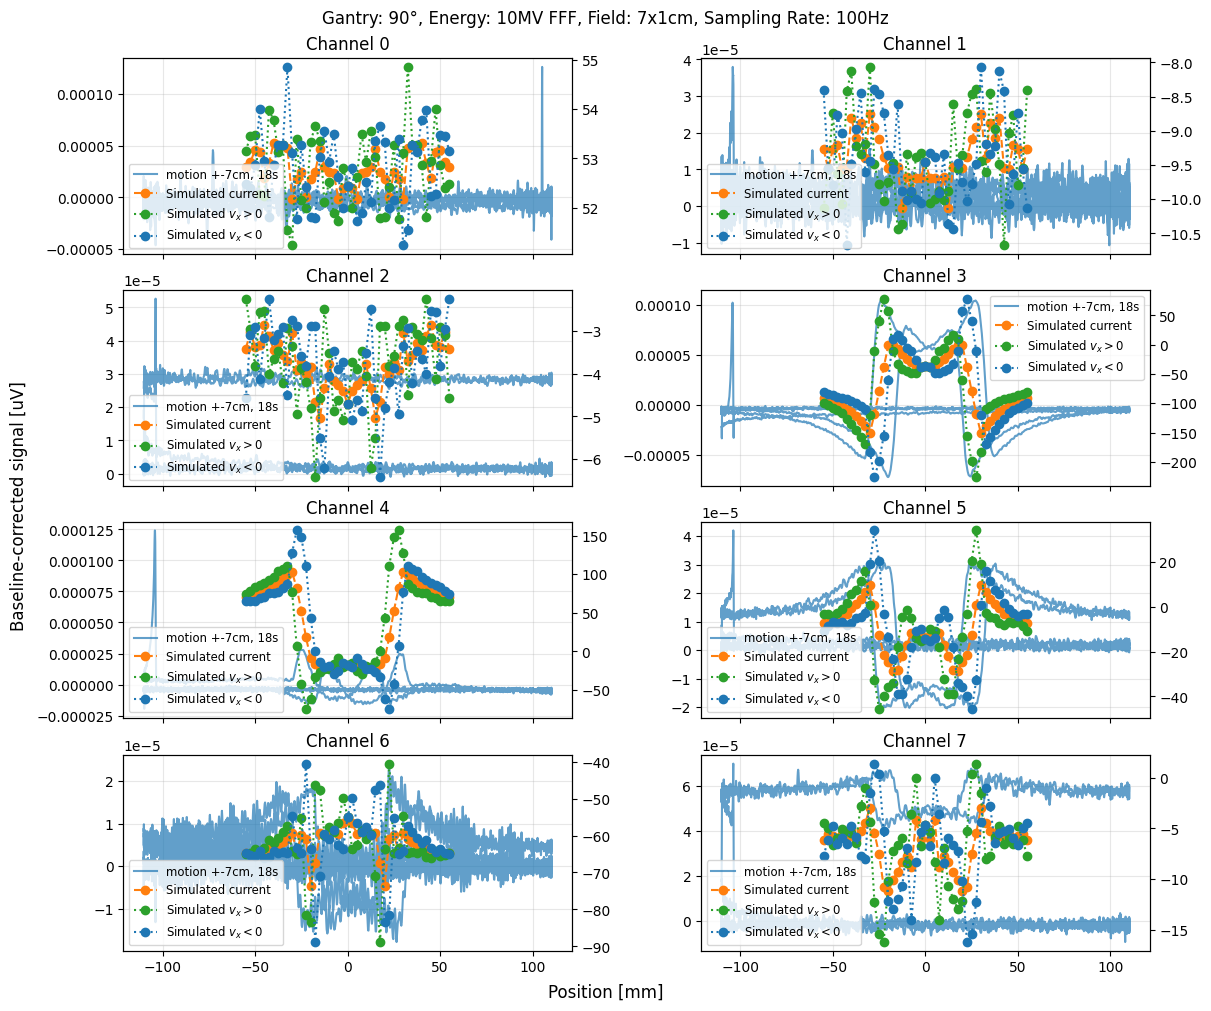

In [6]:
series = SimulationSeries(simulations=simulations, measurement=measurement)

series.get_simulated_signal(halfwidth=15)
series.plot_all_channels()